# **CLINICAL APPOINTMENT NO- SHOW PREDICTION**

# Dataset Description
## Dataset Source
Hospital Appointment No-Show Prediction Dataset  
Source: Kaggle  
Link: https://www.kaggle.com/datasets/miadul/hospital-appointment-no-show-prediction-dataset/data  

The dataset contains 50,000 synthetic hospital appointment records designed to predict whether a patient will miss a scheduled appointment.

Target Variable:
- no_show (0 = Show, 1 = No-Show)

------------------------------------------------------------

## Input Features and Description

1. patient_id  
   Unique identifier for each patient record.

2. age  
   Age of the patient (numerical).

3. gender  
   Gender of the patient (Male / Female).

4. city_type  
   Type of residential area (Urban / Suburban / Other).

5. distance_km  
   Distance between patient’s residence and hospital (in kilometers).

6. travel_time_min  
   Estimated travel time to hospital (in minutes).

7. appointment_day  
   Day of the week when appointment is scheduled.

8. appointment_time_slot  
   Time slot of appointment (Morning / Afternoon / Evening).

9. department  
   Medical department or specialty (Cardiology, Pediatrics, etc.).

10. waiting_days  
    Number of days between booking date and appointment date.

11. previous_appointments  
    Total number of previous hospital appointments attended.

12. previous_no_shows  
    Number of previous missed appointments.

13. diabetes  
    Binary indicator (0 = No, 1 = Yes).

14. hypertension  
    Binary indicator (0 = No, 1 = Yes).

15. chronic_disease  
    Binary indicator (0 = No, 1 = Yes).

16. sms_reminder  
    Indicates whether SMS reminder was sent (0 = No, 1 = Yes).

17. email_reminder  
    Indicates whether email reminder was sent (0 = No, 1 = Yes).

18. num_reminders  
    Total number of reminders sent to the patient.

19. employment_status  
    Employment category (Employed / Student / Other).

20. education_level  
    Education level (Primary / Secondary / Higher).

21. insurance_status  
    Insurance coverage status (Insured / Uninsured).

22. rainy_day  
    Indicates whether appointment day had rainfall (0 = No, 1 = Yes).

23. public_holiday  
    Indicates whether appointment day was a public holiday (0 = No, 1 = Yes).

------------------------------------------------------------

## Output Variable

24. no_show  
    0 → Patient attended the appointment  
    1 → Patient missed the appointment  

------------------------------------------------------------

Objective:
Build a supervised machine learning classification model to predict the probability of a patient missing their scheduled appointment using demographic, medical, behavioral, communication, and environmental features.

### 📌 **1. IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV , cross_val_score

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , roc_auc_score

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

primary_color = "#2E86C1"
secondary_color = "#117A65"
warning_color = "#C0392B"
neutral_color = "#7B7D7D"

sns.set_palette([primary_color, secondary_color, warning_color])

### **📌 2. LOAD DATA**

In [ ]:
df = pd.read_csv("hospital_appointment_no_show_50000.csv")

### **📌 3. DATASET INFO**

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.info()

Shape: (50000, 24)

Columns:
 ['patient_id', 'age', 'gender', 'city_type', 'distance_km', 'travel_time_min', 'appointment_day', 'appointment_time_slot', 'department', 'waiting_days', 'previous_appointments', 'previous_no_shows', 'diabetes', 'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder', 'num_reminders', 'employment_status', 'education_level', 'insurance_status', 'rainy_day', 'public_holiday', 'no_show']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   gender                 50000 non-null  object 
 3   city_type              50000 non-null  object 
 4   distance_km            50000 non-null  float64
 5   travel_time_min        50000 non-null  float64
 6   appointment_day        50000 non-null  ob

In [ ]:
df.describe()

,patient_id,age,distance_km,travel_time_min,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,chronic_disease,sms_reminder,email_reminder,num_reminders,rainy_day,public_holiday,no_show
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,50.937700,9.987357,29.990284,6.993540,5.001520,1.247080,0.153160,0.200360,0.101660,0.703680,0.499820,1.504500,0.201600,0.099640,0.772920
std,14433.901067,19.373208,7.068633,22.423286,2.645312,2.236814,1.121203,0.360145,0.400274,0.302204,0.456638,0.500005,0.816133,0.401199,0.299522,0.418949
min,1.000000,18.000000,0.017213,0.053881,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,34.000000,4.818075,13.923424,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,25000.500000,51.000000,8.357070,24.480817,7.000000,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,1.000000
75%,37500.250000,68.000000,13.412429,40.087056,9.000000,6.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000
max,50000.000000,84.000000,67.365723,232.898577,19.000000,17.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


In [ ]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object','bool']).columns

print("Numerical Columns:", list(numerical_cols))
print("\nCategorical Columns:",list(categorical_cols))

Numerical Columns: ['patient_id', 'age', 'distance_km', 'travel_time_min', 'waiting_days', 'previous_appointments', 'previous_no_shows', 'diabetes', 'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder', 'num_reminders', 'rainy_day', 'public_holiday', 'no_show']

Categorical Columns: ['gender', 'city_type', 'appointment_day', 'appointment_time_slot', 'department', 'employment_status', 'education_level', 'insurance_status']


In [ ]:
target = "no_show" if "no_show" in df.columns else None
target

'no_show'

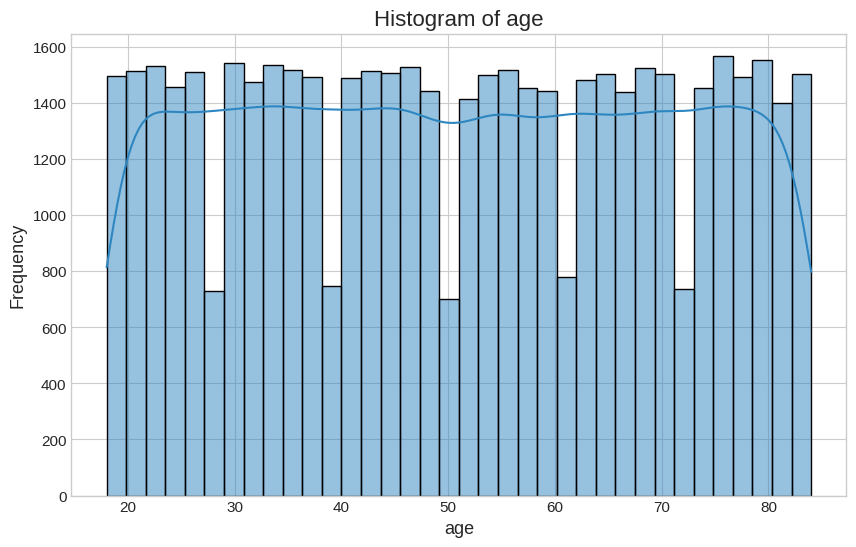

In [ ]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title(f"Histogram of {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.show()

Text(0, 0.5, 'Frequency')

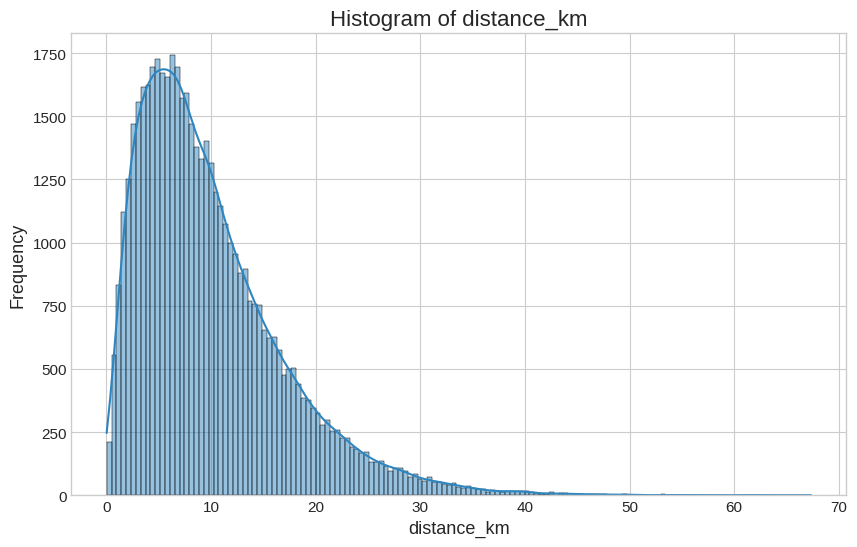

In [ ]:
plt.figure()
sns.histplot(df['distance_km'], kde=True)
plt.title(f"Histogram of {'distance_km'}")
plt.xlabel('distance_km')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

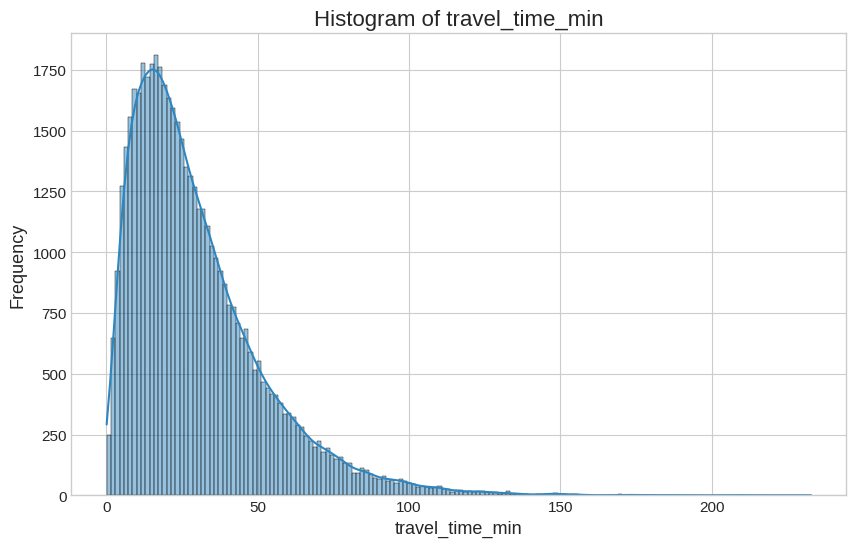

In [ ]:
plt.figure()
sns.histplot(df['travel_time_min'], kde=True)
plt.title(f"Histogram of {'travel_time_min'}")
plt.xlabel('travel_time_min')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

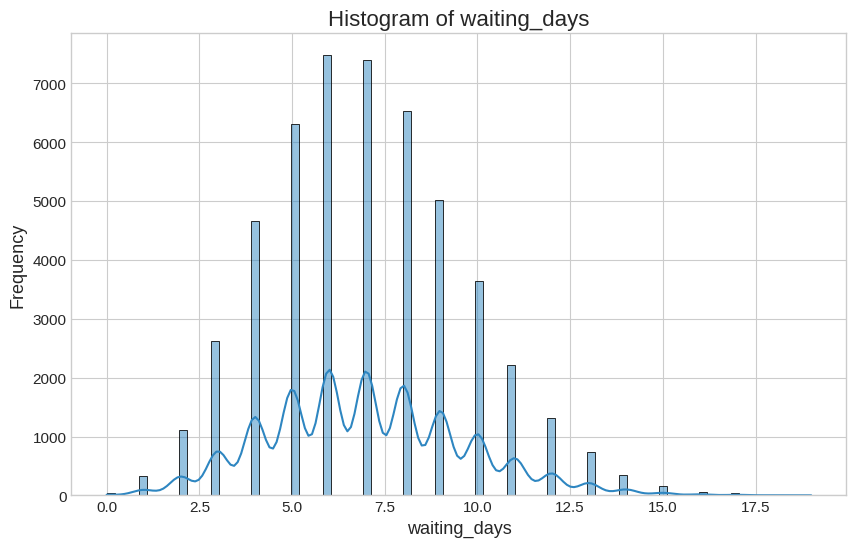

In [ ]:
plt.figure()
sns.histplot(df['waiting_days'], kde=True)
plt.title(f"Histogram of {'waiting_days'}")
plt.xlabel('waiting_days')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

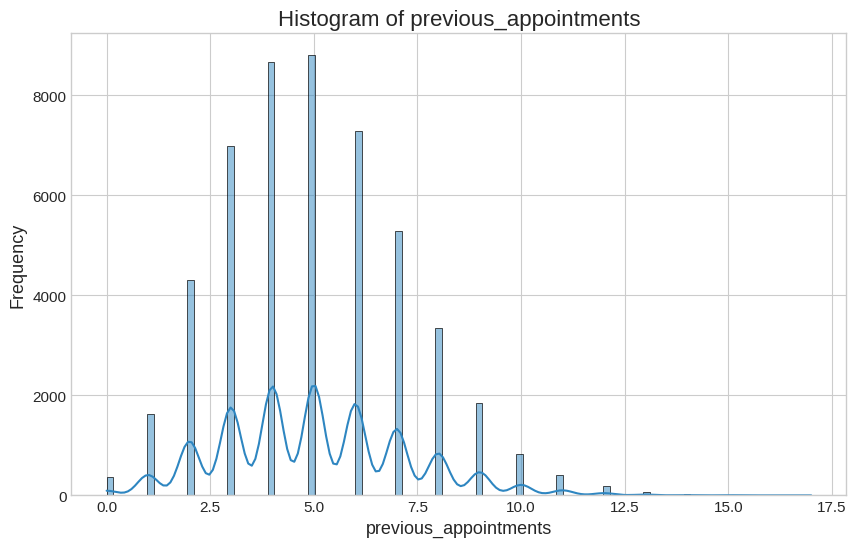

In [ ]:
plt.figure()
sns.histplot(df['previous_appointments'], kde=True)
plt.title(f"Histogram of {'previous_appointments'}")
plt.xlabel('previous_appointments')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

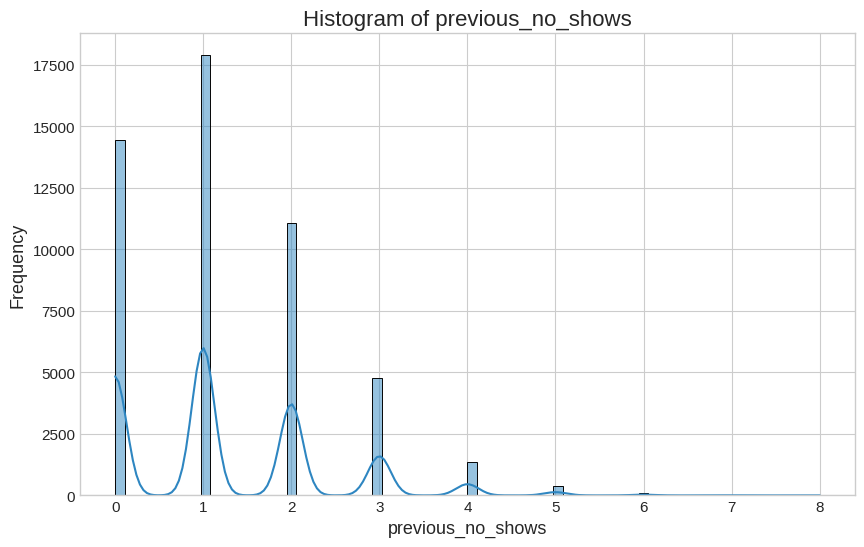

In [ ]:
plt.figure()
sns.histplot(df['previous_no_shows'], kde=True)
plt.title(f"Histogram of {'previous_no_shows'}")
plt.xlabel('previous_no_shows')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

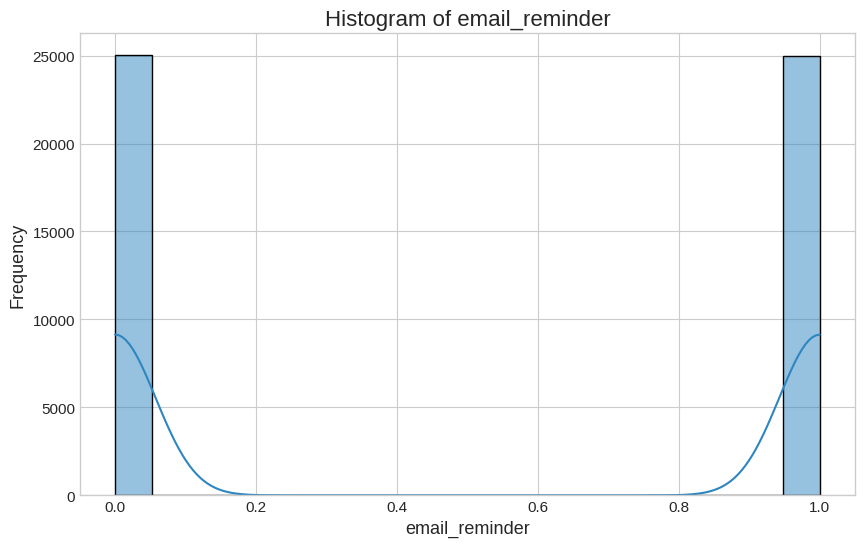

In [ ]:
plt.figure()
sns.histplot(df['email_reminder'], kde=True)
plt.title(f"Histogram of {'email_reminder'}")
plt.xlabel('email_reminder')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

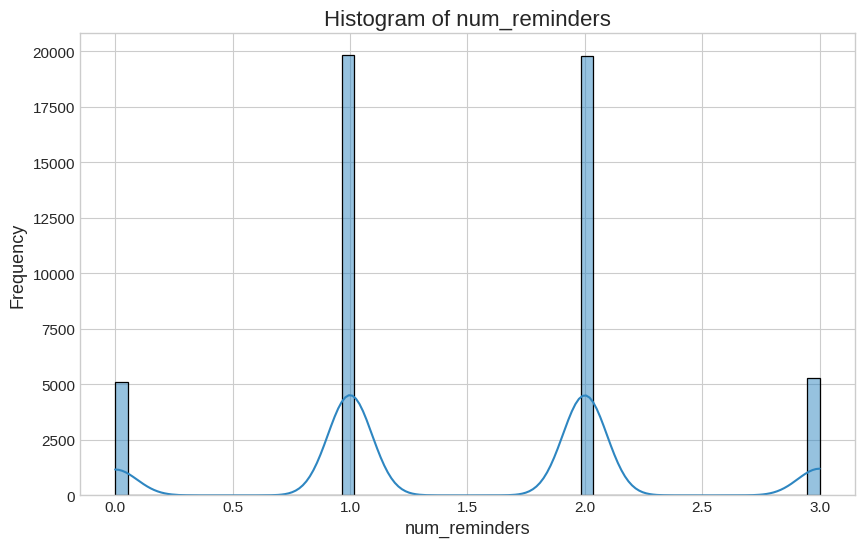

In [ ]:
plt.figure()
sns.histplot(df['num_reminders'], kde=True)
plt.title(f"Histogram of {'num_reminders'}")
plt.xlabel('num_reminders')
plt.ylabel("Frequency")

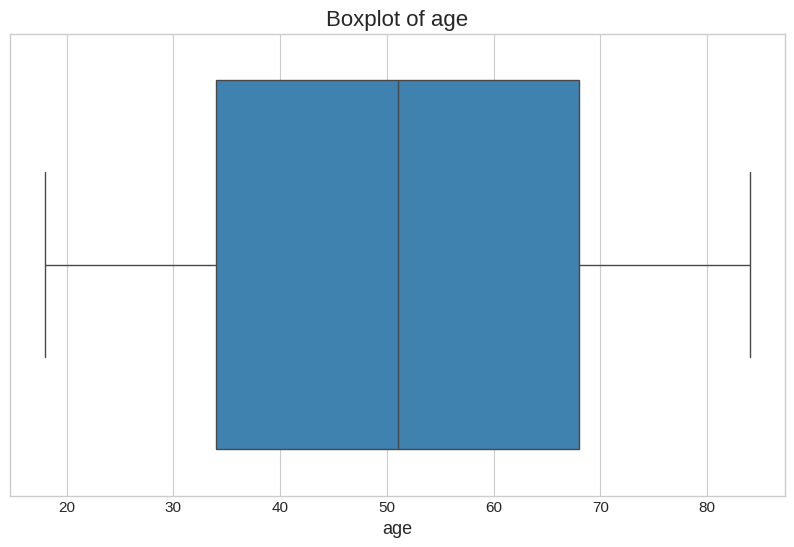

In [ ]:
plt.figure()
sns.boxplot(x=df['age'])
plt.title(f"Boxplot of {'age'}")
plt.xlabel('age')
plt.show()

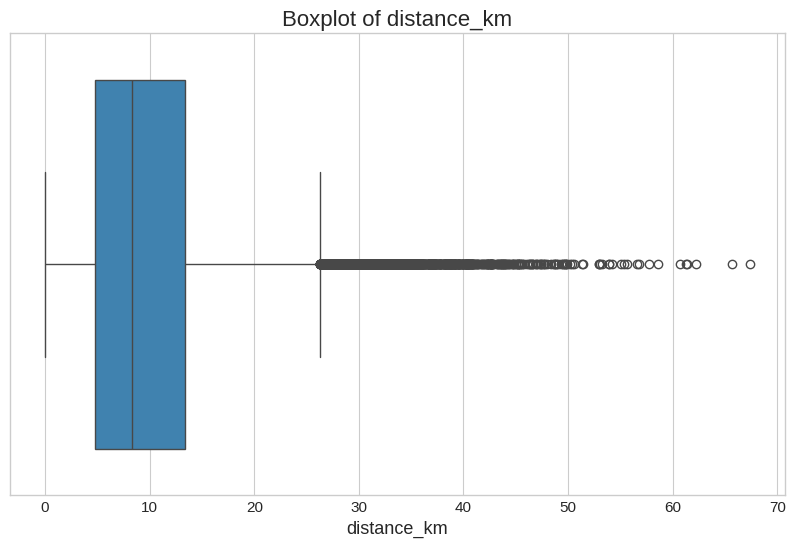

In [ ]:
plt.figure()
sns.boxplot(x=df['distance_km'])
plt.title(f"Boxplot of {'distance_km'}")
plt.xlabel('distance_km')
plt.show()

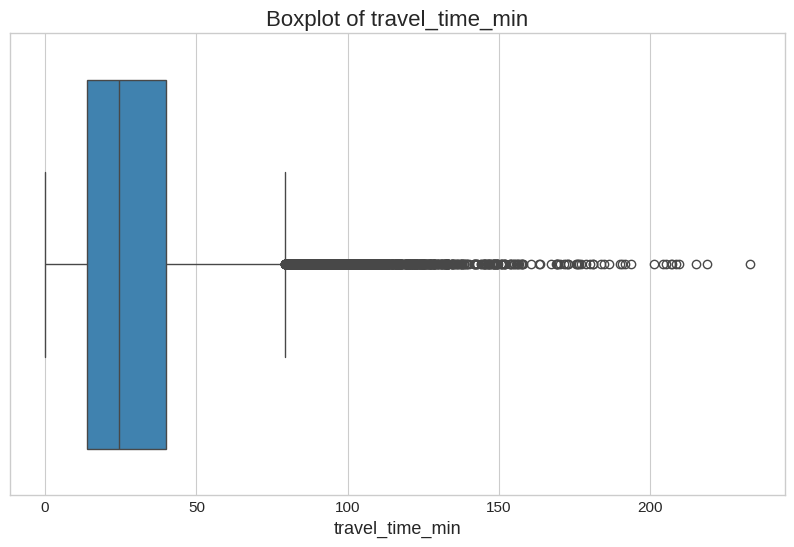

In [ ]:
plt.figure()
sns.boxplot(x=df['travel_time_min'])
plt.title(f"Boxplot of {'travel_time_min'}")
plt.xlabel('travel_time_min')
plt.show()

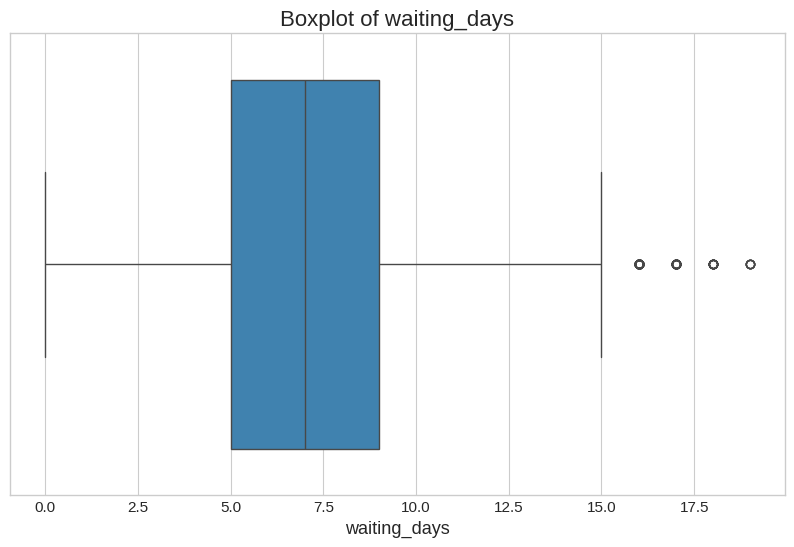

In [ ]:
plt.figure()
sns.boxplot(x=df['waiting_days'])
plt.title(f"Boxplot of {'waiting_days'}")
plt.xlabel('waiting_days')
plt.show()

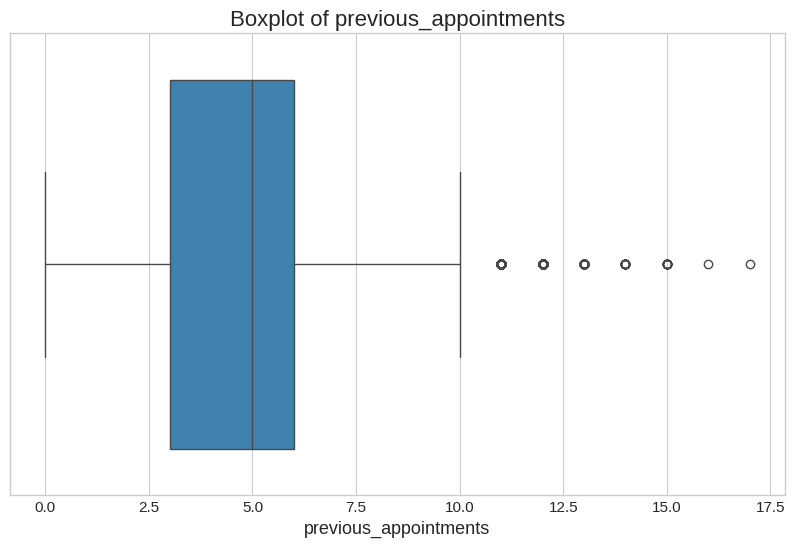

In [ ]:
plt.figure()
sns.boxplot(x=df['previous_appointments'])
plt.title(f"Boxplot of {'previous_appointments'}")
plt.xlabel('previous_appointments')
plt.show()

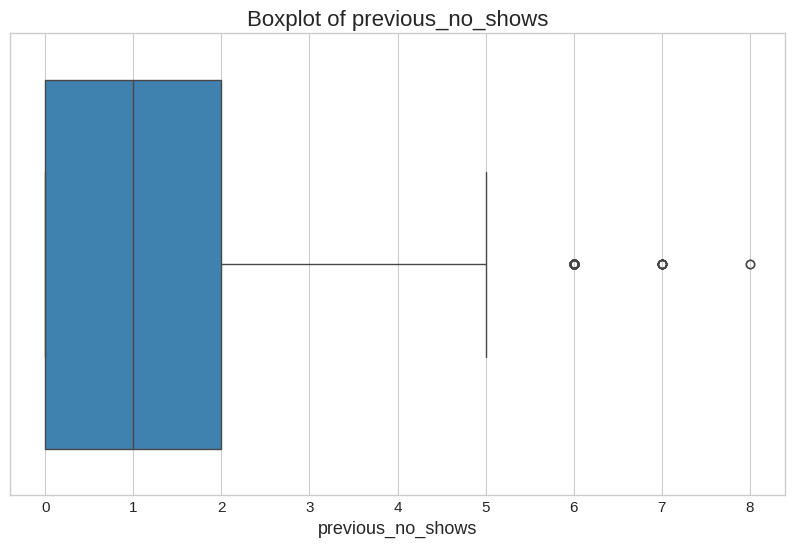

In [ ]:
plt.figure()
sns.boxplot(x=df['previous_no_shows'])
plt.title(f"Boxplot of {'previous_no_shows'}")
plt.xlabel('previous_no_shows')
plt.show()

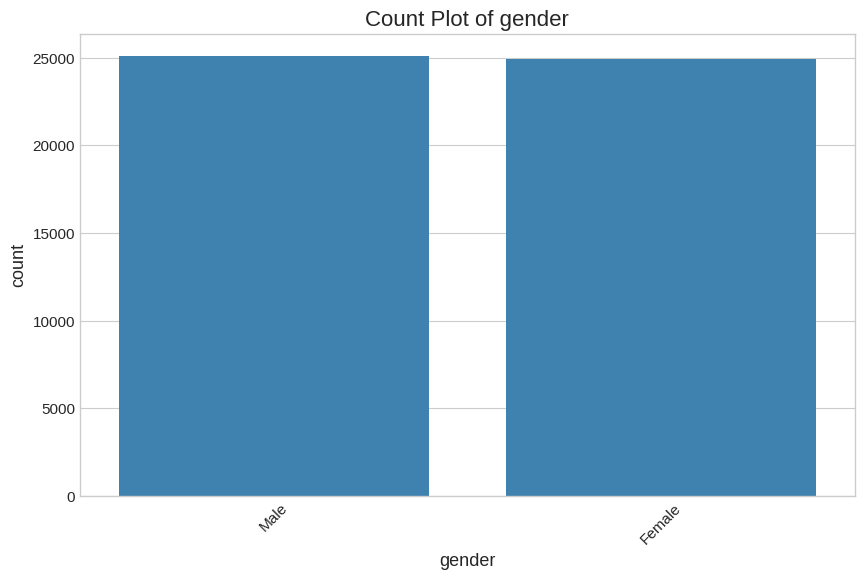

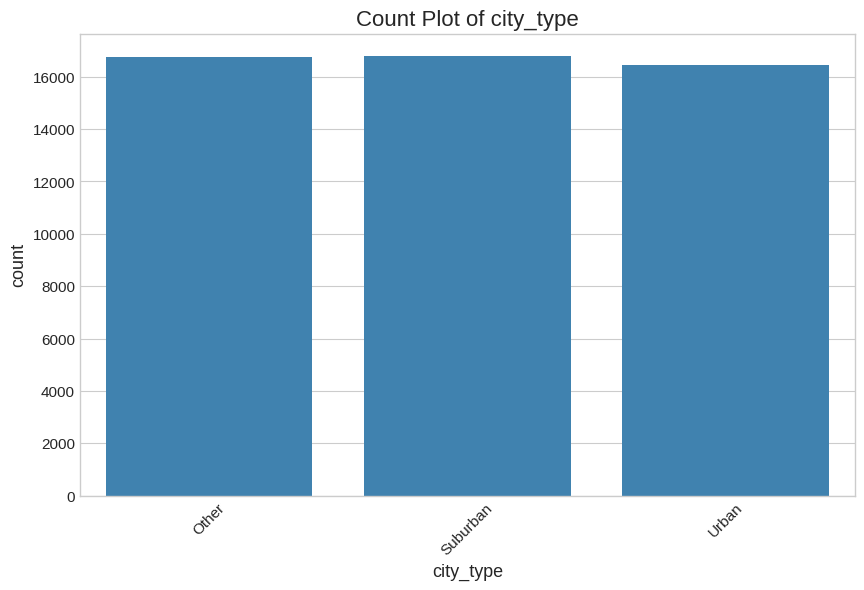

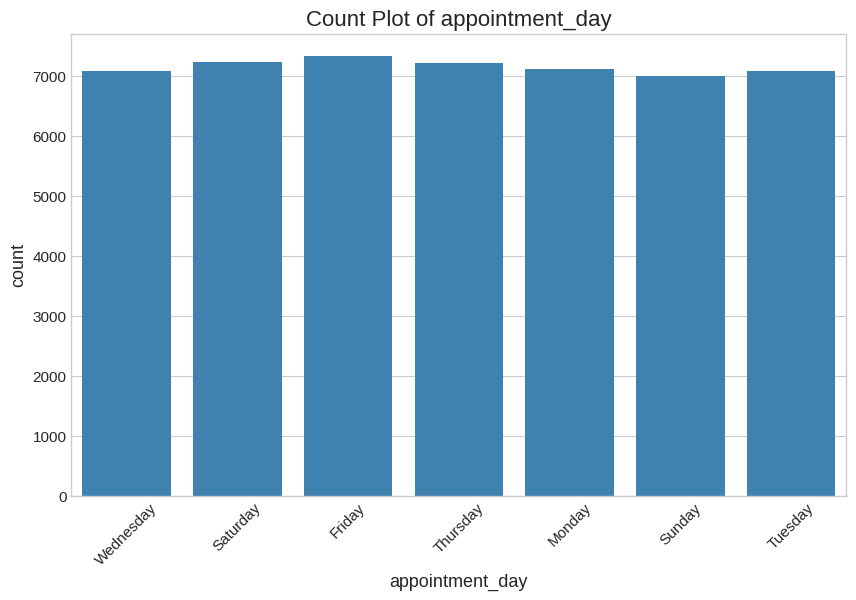

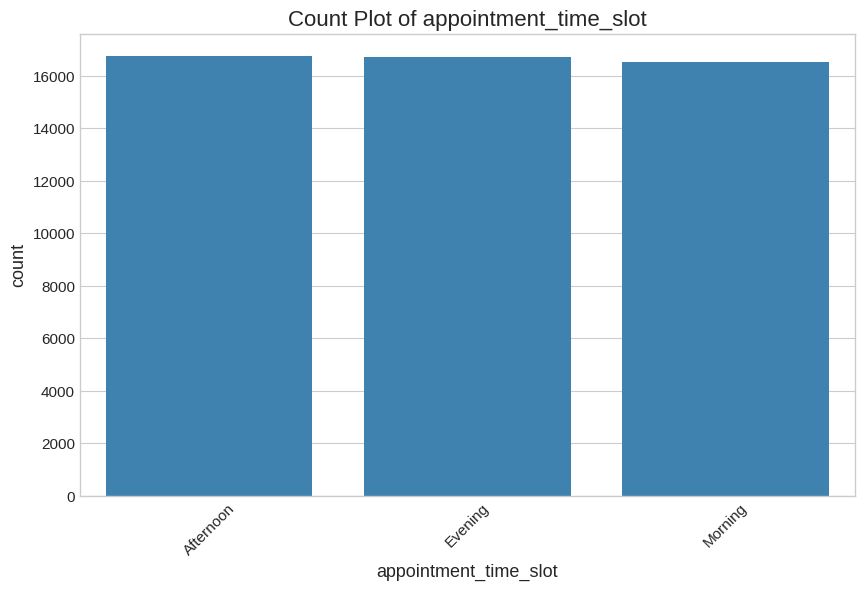

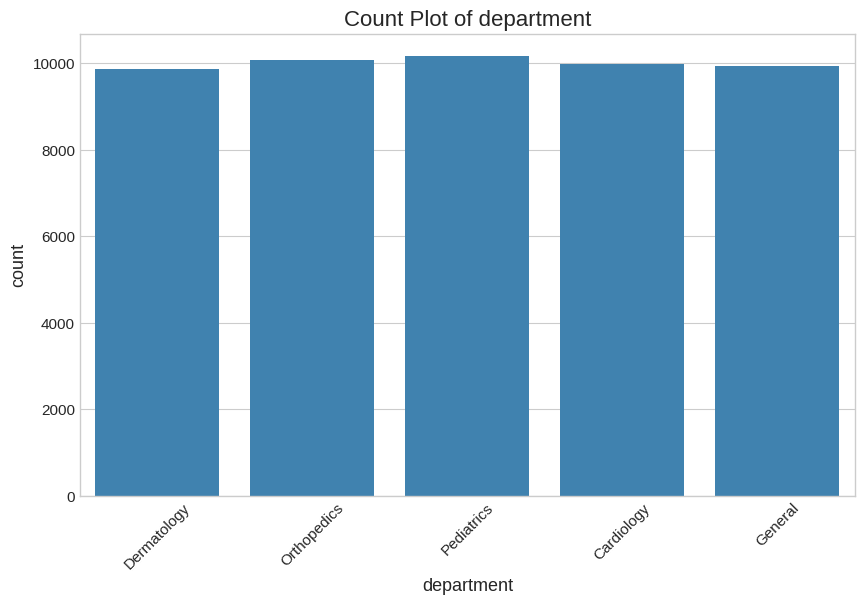

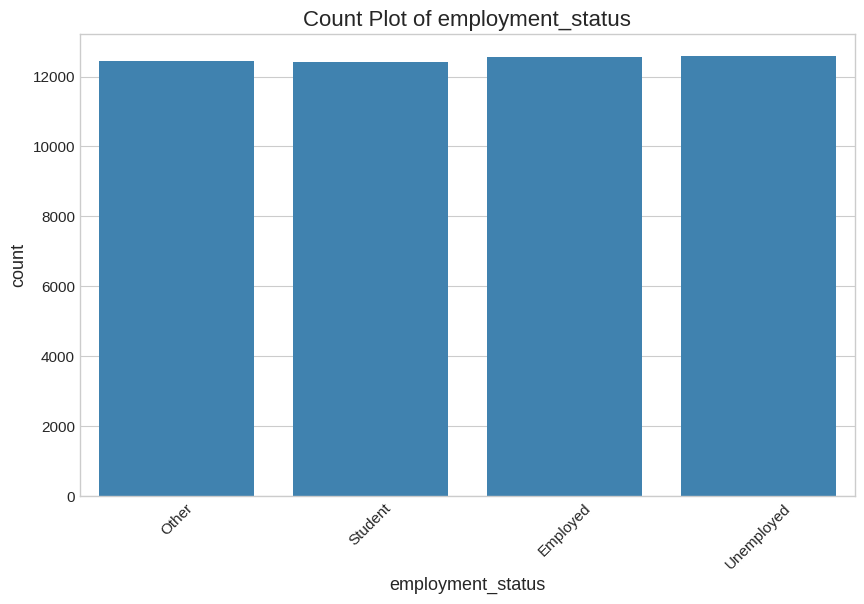

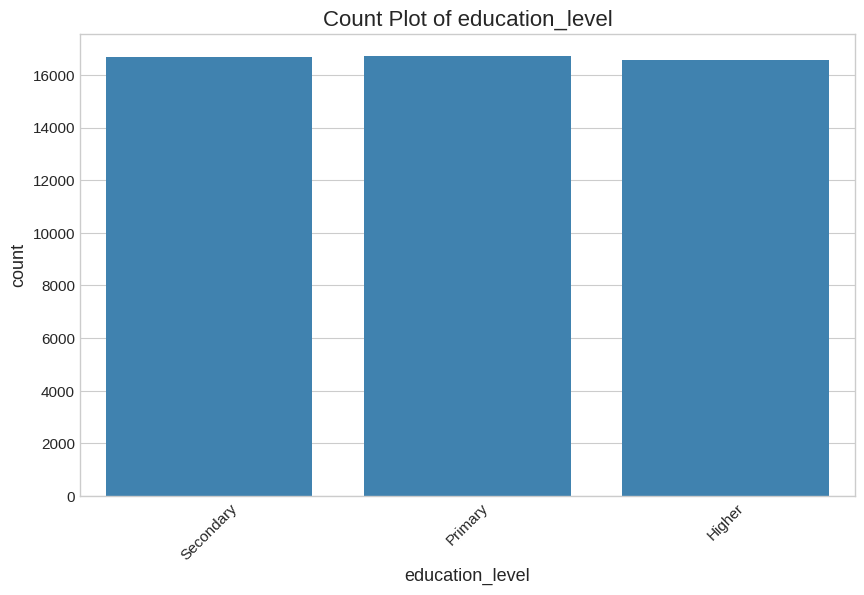

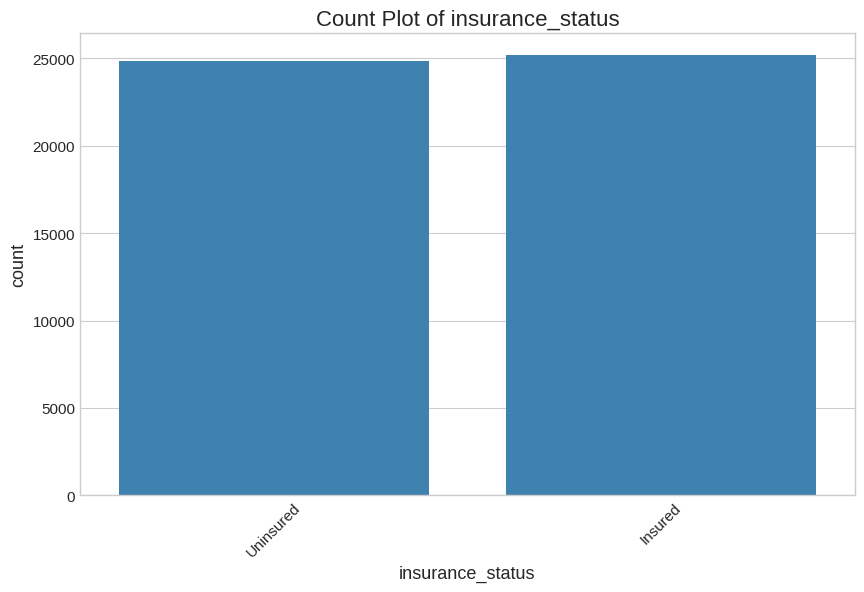

In [ ]:
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

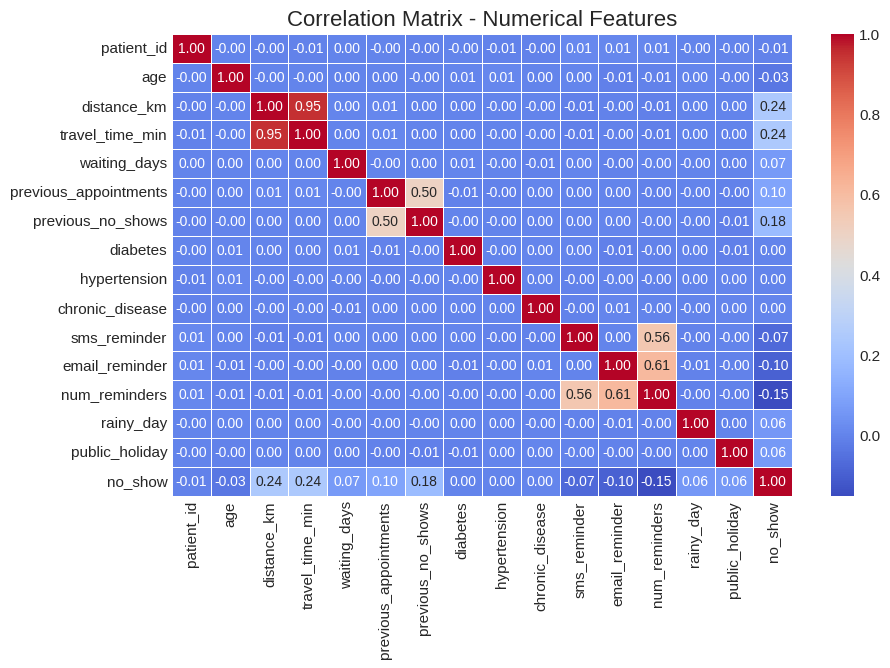

In [ ]:
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Matrix - Numerical Features")
plt.show()

### **📌 4. FEATURE ENGINEERING**

Required Features:

Lead Time, History, Day/Time, Department

In [ ]:
df.drop("patient_id", axis=1, inplace=True)

In [ ]:
df.rename(columns={"waiting_days": "lead_time"}, inplace=True)

In [ ]:
df["no_show_rate"] = np.where(
    df["previous_appointments"] > 0,
    df["previous_no_shows"] / df["previous_appointments"],
    0
)

In [ ]:
df["is_new_patient"] = (df["previous_appointments"] == 0).astype(int) 

In [ ]:
df["high_risk_patient"] = (df["previous_no_shows"] >= 2).astype(int)

In [ ]:
df["travel_burden"] = df["distance_km"] * df["travel_time_min"]
df["long_distance"] = (df["distance_km"] > 15).astype(int)
df["high_travel_time"] = (df["travel_time_min"] > 45).astype(int)

In [ ]:
df["long_lead_time"] = (df["lead_time"] > 21).astype(int)
df["short_lead_time"] = (df["lead_time"] <= 3).astype(int)
df["same_day"] = (df["lead_time"] == 0).astype(int)
df["is_weekend"] = df["appointment_day"].isin(["Saturday", "Sunday"]).astype(int)

In [ ]:
df["is_elderly"] = (df["age"] >= 65).astype(int)
df["is_young_adult"] = ((df["age"] >= 18) & (df["age"] <= 30)).astype(int)
df["has_chronic_condition"] = (
    (df["diabetes"] == 1) | (df["hypertension"] == 1) | (df["chronic_disease"] == 1)
).astype(int)
df["multiple_chronic"] = (
    df["diabetes"] + df["hypertension"] + df["chronic_disease"] >= 2
).astype(int)

In [ ]:
df["got_reminder"] = ((df["sms_reminder"] == 1) | (df["email_reminder"] == 1)).astype(int)
df["multiple_reminders"] = (df["num_reminders"] >= 2).astype(int)
df["is_uninsured"] = (df["insurance_status"] == "Uninsured").astype(int)
df["is_unemployed"] = (df["employment_status"] == "Unemployed").astype(int)
df["risk_distance"] = df["high_risk_patient"] * df["long_distance"]
df["uninsured_distance"] = df["is_uninsured"] * df["long_distance"]
df["young_long_wait"] = df["is_young_adult"] * df["long_lead_time"]
df["rain_distance"] = df["rainy_day"] * df["long_distance"]

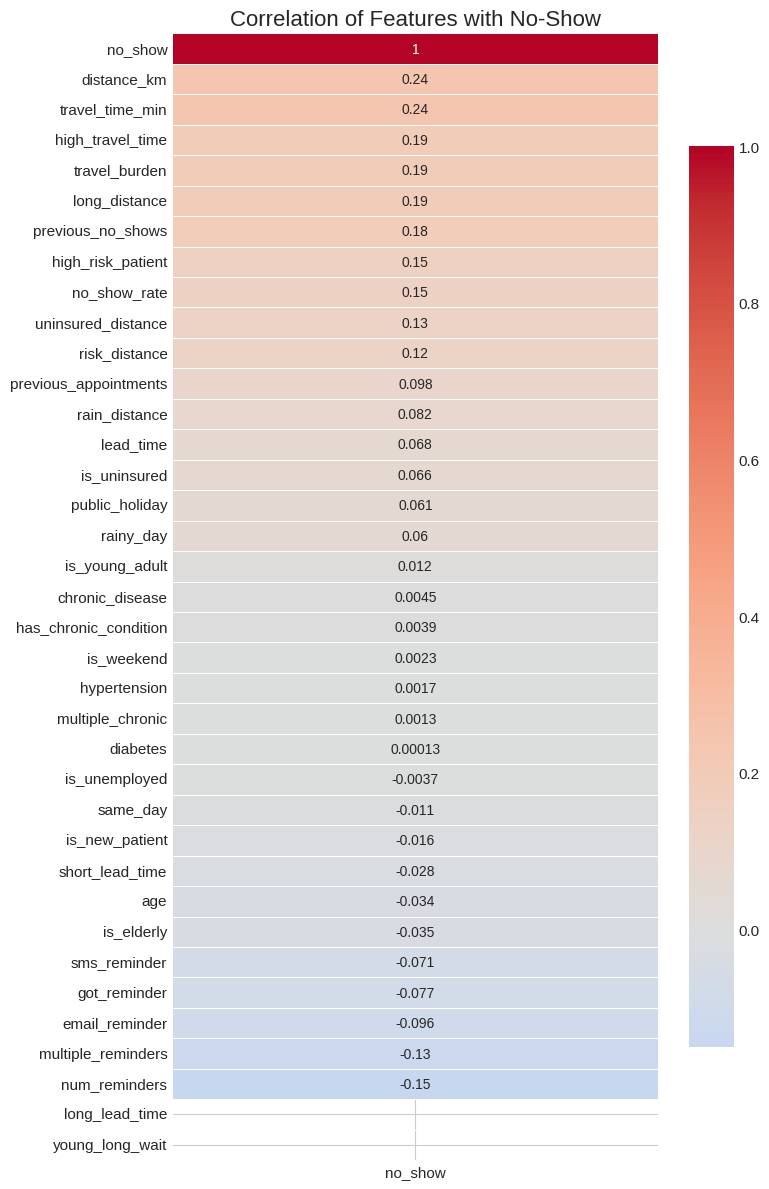

In [ ]:
corr_target = df.corr(numeric_only=True)[["no_show"]].sort_values(by="no_show", ascending=False)

plt.figure(figsize=(8, 12))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation of Features with No-Show", fontsize=16)
plt.tight_layout()
plt.show()

### **📌 5. DEFINE FEATURES AND TARGET**

In [ ]:
X = df.drop("no_show", axis=1)
y = df["no_show"]

### **📌 6. SPLIT DATA**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 , stratify=y
)

### **📌 7. PREPROCESSING PIPELINE**

In [ ]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

In [ ]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['age', 'distance_km', 'travel_time_min', 'lead_time',
       'previous_appointments', 'previous_no_shows', 'diabetes',
       'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder',
       'num_reminders', 'rainy_day', 'public_holiday', 'no_show_rate',
       'is_new_patient', 'high_risk_patient', 'travel_burden', 'long_distance',
       'high_travel_time', 'long_lead_time', 'short_lead_time', 'same_day',
       'is_weekend', 'is_elderly', 'is_young_adult', 'has_chronic_condition',
       'multiple_chronic', 'got_reminder', 'multiple_reminders',
       'is_uninsured', 'is_unemployed', 'risk_distance', 'uninsured_distance',
       'young_long_wait', 'rain_distance'],
      dtype='object')
Categorical Columns: Index(['gender', 'city_type', 'appointment_day', 'appointment_time_slot',
       'department', 'employment_status', 'education_level',
       'insurance_status'],
      dtype='object')


###  🔹 **7.1. Handle Missing Values**

In [ ]:
X_train.isnull().sum()

,0
age,0
gender,0
city_type,0
distance_km,0
travel_time_min,0
appointment_day,0
appointment_time_slot,0
department,0
lead_time,0
previous_appointments,0


In [ ]:
X_test.isnull().sum()

,0
age,0
gender,0
city_type,0
distance_km,0
travel_time_min,0
appointment_day,0
appointment_time_slot,0
department,0
lead_time,0
previous_appointments,0


In [ ]:
for col in numerical_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

###🔹 **7.2. Encoding Categorical Variables**

Categorical variables were divided into nominal and ordinal types to apply appropriate encoding strategies.

🔹 Nominal Variables (One-Hot Encoding)

The following variables have no intrinsic order:

*	gender
*	city_type
*	appointment_day
*	appointment_time_slot
*	department
*	employment_status
*	insurance_status

These were encoded using One-Hot Encoding to prevent the model from assuming artificial ordinal relationships.

In [ ]:
nominal_cols = [
    "gender",
    "city_type",
    "appointment_day",
    "appointment_time_slot",
    "department",
    "employment_status",
    "insurance_status"
]

X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

### **🔹 Ordinal Variable (Ordinal Encoding)**

The variable education_level has a natural ranking:

Primary < Secondary < Higher

Therefore, ordinal encoding was applied using a manual mapping:

In [ ]:
education_map = {
    "Primary": 1,
    "Secondary": 2,
    "Higher": 3
}

X_train["education_level"] = X_train["education_level"].map(education_map)
X_test["education_level"] = X_test["education_level"].map(education_map)

###🔹 **7.3. StandardScaler**

In [ ]:
X_train_columns = X_train.columns

In [ ]:
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr = scaler.transform(X_test)

### **📌 8. MODEL TRAINING**

###🔹 **8.1. LOGISTIC REGRESSION**

In [ ]:
results = []

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    C=0.1,
    class_weight='balanced',
    random_state=42
)

logistic_model.fit(X_train_lr, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [ ]:
y_pred_log = logistic_model.predict(X_test_lr)
y_prob_log = logistic_model.predict_proba(X_test_lr)[:, 1]

In [ ]:
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Results")
print("Accuracy :", acc_log)
print("Precision:", prec_log)
print("Recall   :", rec_log)
print("F1 Score :", f1_log)
print("ROC-AUC  :", auc_log)

Logistic Regression Results
Accuracy : 0.6745
Precision: 0.8904013961605585
Recall   : 0.6601112692456981
F1 Score : 0.7581543948287391
ROC-AUC  : 0.7637688612811385


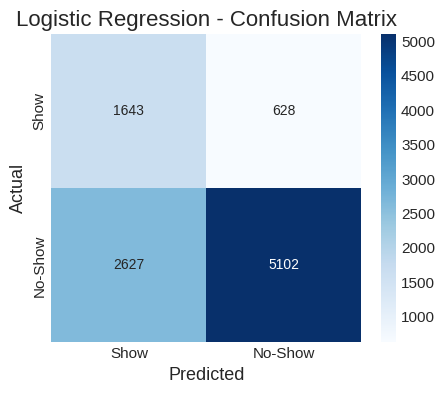

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": acc_log,
    "Precision": prec_log,
    "Recall": rec_log,
    "F1": f1_log,
    "ROC-AUC": auc_log
})

###🔹 **8.2. DECISION TREE**

In [ ]:
decision_tree_model = DecisionTreeClassifier(max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    class_weight='balanced',
    random_state=42
)
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=15, min_samples_split=30,
                       random_state=42)

In [ ]:
y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

In [ ]:
acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("Accuracy :", acc_tree)
print("Precision:", prec_tree)
print("Recall   :", rec_tree)
print("F1 Score :", f1_tree)
print("ROC-AUC  :", auc_tree)

Decision Tree Results
Accuracy : 0.651
Precision: 0.8728232189973615
Recall   : 0.641997671108811
F1 Score : 0.7398240644103176
ROC-AUC  : 0.7150101874034436


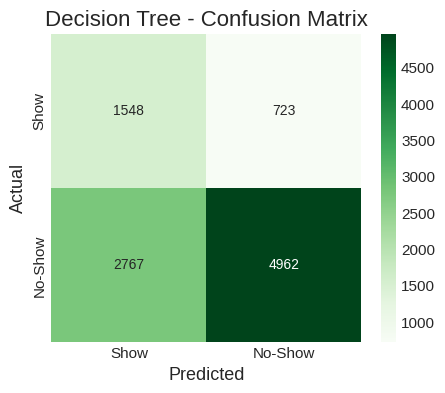

In [ ]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": acc_tree,
    "Precision": prec_tree,
    "Recall": rec_tree,
    "F1": f1_tree,
    "ROC-AUC": auc_tree
})

###🔹 **8.3. RANDOM FOREST**

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [ ]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", auc_rf)

Random Forest Results
Accuracy : 0.718
Precision: 0.8683776076842263
Recall   : 0.7486091344287747
F1 Score : 0.8040578098943858
ROC-AUC  : 0.755117871986643


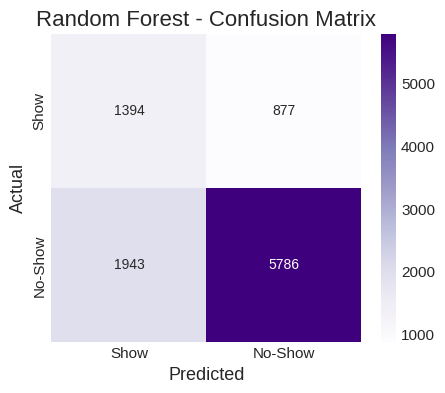

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results.append({
    "Model": "Random Forest",
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1": f1_rf,
    "ROC-AUC": auc_rf
})

###🔹 **8.4. XGBoost Classifier**

In [ ]:
xgboost_model =  XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgboost_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xg = xgboost_model.predict(X_test)
y_prob_xg = xgboost_model.predict_proba(X_test)[:, 1]

In [ ]:
acc_xg = accuracy_score(y_test, y_pred_xg)
prec_xg = precision_score(y_test, y_pred_xg)
rec_xg = recall_score(y_test, y_pred_xg)
f1_xg = f1_score(y_test, y_pred_xg)
auc_xg = roc_auc_score(y_test, y_prob_xg)

print("Random Forest Results")
print("Accuracy :", acc_xg)
print("Precision:", prec_xg)
print("Recall   :", rec_xg)
print("F1 Score :", f1_xg)
print("ROC-AUC  :", auc_xg)

Random Forest Results
Accuracy : 0.7822
Precision: 0.806515737161789
Recall   : 0.9448829085263294
F1 Score : 0.8702335557673975
ROC-AUC  : 0.7522343608131441


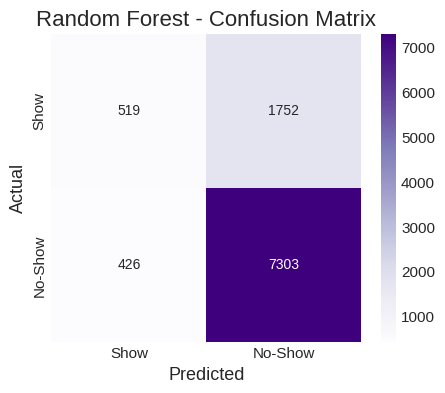

In [ ]:
cm_xg = confusion_matrix(y_test, y_pred_xg)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xg, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results.append({
    "Model": "XGBoost",
    "Accuracy": acc_xg,
    "Precision": prec_xg,
    "Recall": rec_xg,
    "F1": f1_xg,
    "ROC-AUC": auc_xg
})

### **📌 9. COMPARE ALL MODELS**


MODEL COMPARISON
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression    0.6745   0.890401 0.660111 0.758154 0.763769
      Random Forest    0.7180   0.868378 0.748609 0.804058 0.755118
            XGBoost    0.7822   0.806516 0.944883 0.870234 0.752234
      Decision Tree    0.6510   0.872823 0.641998 0.739824 0.715010


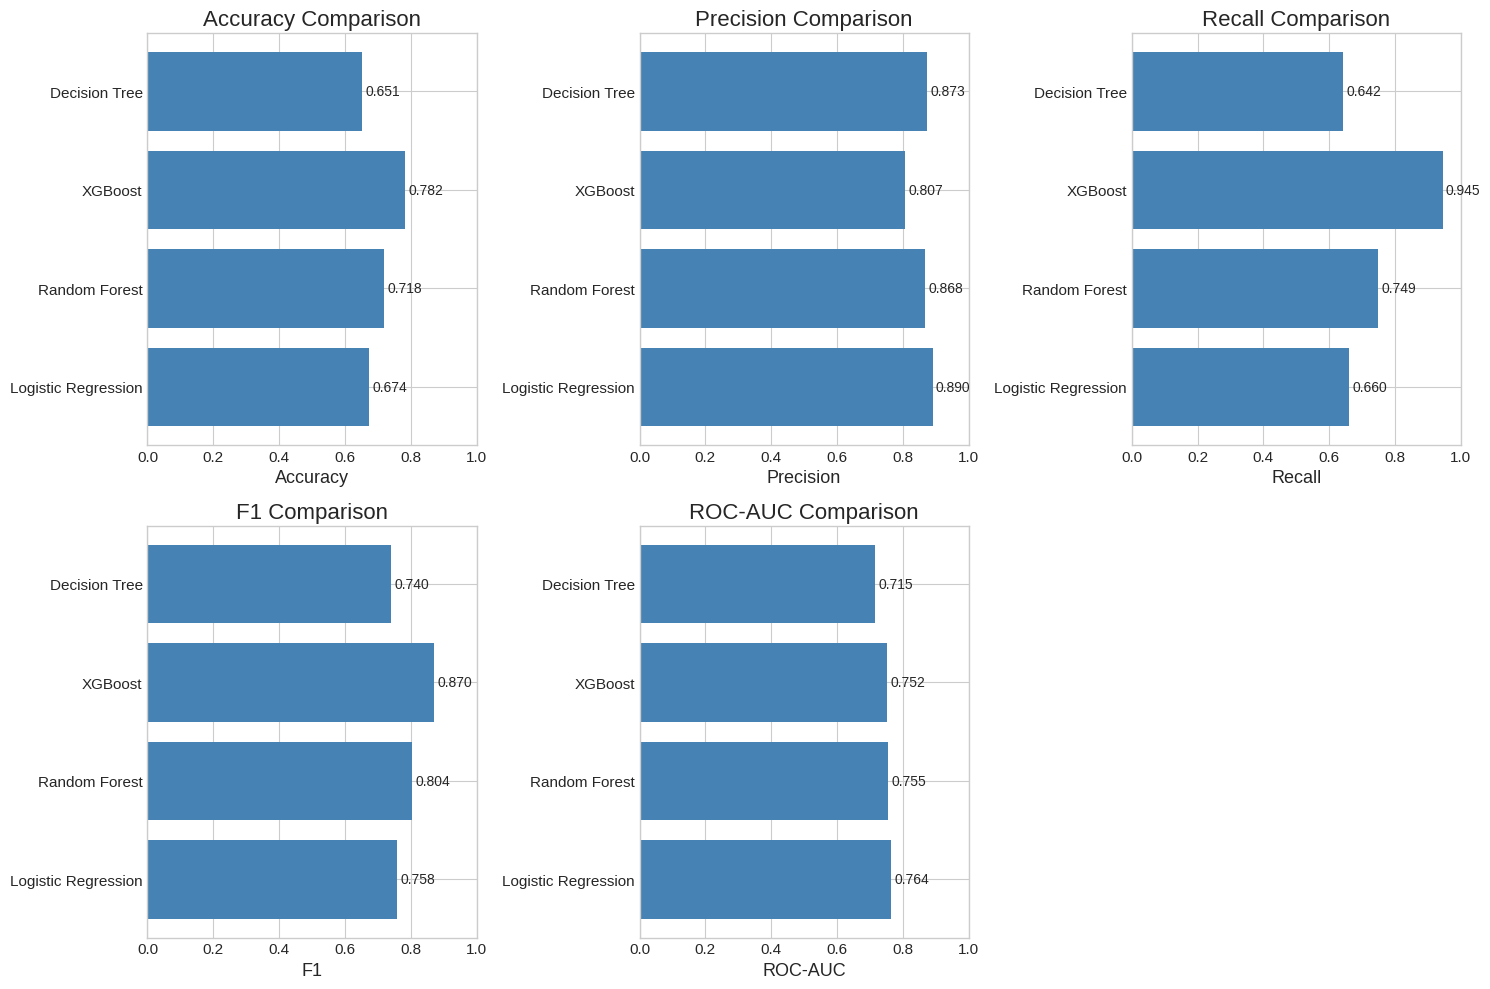


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
              Feature  Importance
    previous_no_shows    0.091921
        travel_burden    0.081673
        num_reminders    0.071110
       public_holiday    0.049575
         no_show_rate    0.038636
            rainy_day    0.038476
      travel_time_min    0.038080
         is_uninsured    0.037044
     high_travel_time    0.033730
            lead_time    0.020095
       email_reminder    0.019986
          distance_km    0.018427
   uninsured_distance    0.016975
                  age    0.016186
previous_appointments    0.015708


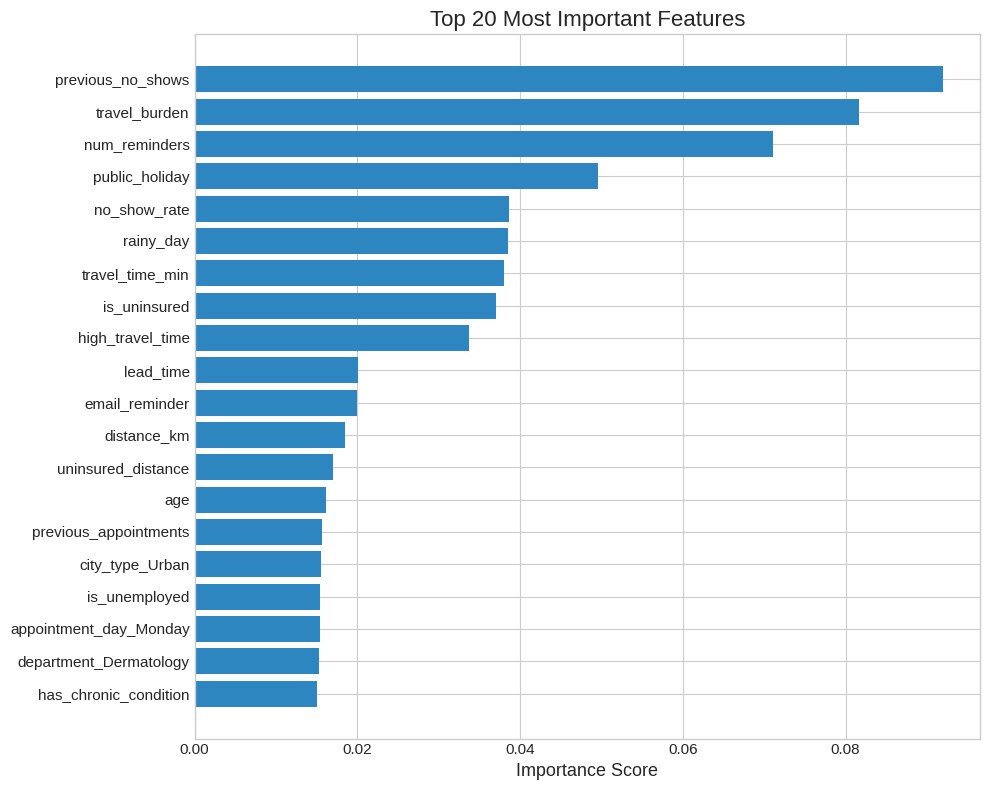

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("ROC-AUC", ascending=False)

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3

    axes[row, col].barh(results_df['Model'], results_df[metric], color='steelblue')
    axes[row, col].set_xlabel(metric)
    axes[row, col].set_xlim([0, 1])
    axes[row, col].set_title(f'{metric} Comparison')

    for i, v in enumerate(results_df[metric]):
        axes[row, col].text(v + 0.01, i, f'{v:.3f}', va='center')


fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

best_model = xgboost_model

importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train_columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top_20 = feature_importance_df.head(20)

plt.barh(range(len(top_20)), top_20['Importance'])
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **📌 STEP 10 — MODEL OPTIMIZATION & DECISION STRATEGY**

### **🔹 10.1 Select Best Model (XGBoost)**

In [ ]:
best_model = xgboost_model
y_prob = y_prob_xg

### **🔹 10.2  CROSS-VALIDATION CHECK**

In [ ]:
cv_scores = cross_val_score(
    xgboost_model,
    X_train_tree,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validated ROC-AUC:", cv_scores.mean())

Cross-Validated ROC-AUC: 0.7515455784396359


### **🔹 10.3 HYPERPARAMETER TUNING**

In [ ]:
param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 300],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring={
        "roc_auc": "roc_auc",
        "recall": "recall",
        "precision": "precision",
        "f1": "f1"
    },
    refit="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_tree, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:25:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5], 'n_estimators': [200, 300],
                         'subsample': [0.8, 1.0]},
             refit='roc_auc',
             scoring={'f1': 'f1', 'precision': 'precision', 'recall': 'recall',
                      'roc_auc': 'roc_auc'},
             verbose=1)

In [ ]:
print("\nBest Cross-Validated ROC-AUC:", grid.best_score_)
print("Best Parameters Found:\n", grid.best_params_)


Best Cross-Validated ROC-AUC: 0.7617577906674734
Best Parameters Found:
 {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


### **🔹 10.4 TRAIN BEST MODEL ON FULL TRAINING DATA**

In [ ]:
best_model = grid.best_estimator_

best_model.fit(X_train_tree, y_train)

y_pred_best = best_model.predict(X_test_tree)
y_prob_best = best_model.predict_proba(X_test_tree)[:, 1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:26:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### **🔹 10.5 TEST PERFORMANCE**

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

Accuracy : 0.7843
Precision: 0.8017764298093587
Recall   : 0.9576918100659852
F1 Score : 0.872825894699605
ROC-AUC  : 0.7623382436714784


### **🔹 10.6 THRESHOLD OPTIMIZATION**

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)

optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.39149204


In [ ]:
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

print("\nAfter Threshold Optimization")
print("Accuracy :", accuracy_score(y_test, y_pred_optimal))
print("Precision:", precision_score(y_test, y_pred_optimal))
print("Recall   :", recall_score(y_test, y_pred_optimal))
print("F1 Score :", f1_score(y_test, y_pred_optimal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))


After Threshold Optimization
Accuracy : 0.7836
Precision: 0.7885512807217671
Recall   : 0.9838271445206366
F1 Score : 0.8754317292194336
ROC-AUC  : 0.7623382436714784


# **FINAL OPTIMIZED MODEL SUMMARY**

In [ ]:
print("\nFINAL MODEL SUMMARY")
print("Chosen Model: Tuned XGBoost")
print(f"Optimal Threshold: {optimal_threshold:.2f}")
print(f"Final ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")
print("High recall ensures most no-shows are detected.")
print("Threshold tuning balances precision and recall for operational deployment.")


FINAL MODEL SUMMARY
Chosen Model: Tuned XGBoost
Optimal Threshold: 0.39
Final ROC-AUC: 0.7623
High recall ensures most no-shows are detected.
Threshold tuning balances precision and recall for operational deployment.
